In [1]:
# Set up the file path, import packages, and define device
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(parent_dir)
print('Parent directory set to:', parent_dir)

# Import general packages
import torch
import numpy as np
from itertools import product, combinations_with_replacement
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.utils.ic import IC

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

# Import Visualization packages
from RL4CRN.utils.visualizations import plot_reactant_product_heatmap, plot_reactant_product_scatter, topology_graph

target_directory = os.path.join(parent_dir, '/local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_4s_5r_SIL')

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
N_CPUs = os.cpu_count() if os.cpu_count() is not None else 1
print(f'Number of CPUs available: {os.cpu_count()}') 

# Define path for the directories: hall of fame and models
base_path_hof = os.path.abspath(os.path.join(target_directory, 'hof'))
base_path_models = os.path.abspath(os.path.join(target_directory, 'models'))
print(f"Current working directory: {os.getcwd()}")
print(f"Base path for halls of fame: {base_path_hof}")
print(f"Base path for models: {base_path_models}")

Parent directory set to: /local0/rossin/git
Using device: cuda
Number of CPUs available: 128
Current working directory: /local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_4s_5r_SIL
Base path for halls of fame: /local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_4s_5r_SIL/hof
Base path for models: /local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_4s_5r_SIL/models


Using device: cuda
Number of CPUs available: 128


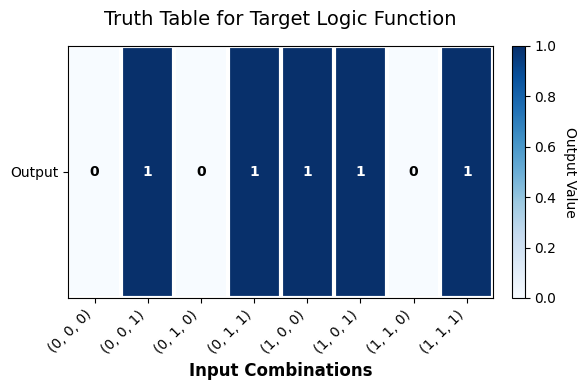

In [2]:
# Flag to resimulate the IOCRN dynamics of the halls of fame
resimulate_flag = False 

# Flag to load generated IOCRNs from trained models
generated_flag = True

# Flag for filtering out repeated IOCRN topologies
filter_flag = True
num_reactions_template = 4

# Parallel simulation flag
parallel_flag = True

# Set number of inputs and species labels
p = 3                                                   # Number of inputs
mak_order = 2                                           # Maximum order of the mass-action reactions

productions = []
dilutions = []
n_inputs = 3
species_labels = [f'X_{i+1}' for i in range(n_inputs)] 

species_labels.append('OUT') # add output species label

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Number of CPUs available: {os.cpu_count()}') 

# %%
from RL4CRN.utils.visualizations import plot_truth_table

# Hyperparameters
max_added_reactions = 8                             # Maximum number of reactions
N_CPUs = os.cpu_count()                             # Number of CPUs          
N = 10*N_CPUs                                       # Number of samples (batch size)    
width = 1024                                        # Width of the neural networks  
depth = 5                                           # Depth of the neural networks 
deep_layer_size = 1024*10                           # Size of the deep layer encoding the CRNs
allow_input_influence = False                       # Allow input influence in the policy
learning_rate = 1e-4                                # Learning rate for the optimizer 
hall_of_fame_size = 30                              # Size of the hall of fame  
entropy_scheduler = {                               # Entropy scheduler parameters 
    'entropy_weight': 1e-3, 
    'topk_entropy_weight' : 1.0,
    'remainder_entropy_weight' : 1.0,
    'entropy_update_coefficient': 1, 
    'entropy_schedule': 1000, 
    'minimum_entropy_weight': 0.0
}
entropy_weights_per_head = {'structure': 2.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0} 
structure_head_temperature = {"target_entropy_ratio_to_max": np.log(5)/np.log(5), "initial_temperature": 1.0, "rate": 0.0, "current_temperature": 1.0}
risk_scheduler = {                                  # Risk scheduler parameters
    'risk': 0.95, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 1000
}
epoch_num = 300                                     # Number of epochs for training
render_schedule = 10                                 # Render every # of epochs
render_mode = {                                     # Mode of the experiment
    'style': 'logger', 
    'task': 'transients + logic', 
    'format': 'image',
    'topology': True,
    'bounds': [2.5]
}
# Ordering specific parameters
ordering_parameters = {
    'enforce_ordering': False,
    'constraint_weight' : float('inf')
}

render_n_best = 10                                                    # Number of best CRNs to plot responses for
render_disregard_percentage = 0.99                                    # Percentage of worst CRNs to disregard in the responses plotting

# Parameter distribution for the reactions added by the agent
continuous_distribution = {"type": 'lognormal_1D'}

# Time horizon for the simulation
t_f = 100                                           # Final time for the simulation
N_t = 1000                                          # Number of time steps
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
# all combination of inputs between 0 and 1 
nums = [0., 1.]
u_list = [np.array(u) for u in product(*[nums for _ in range(n_inputs)])] # list of input combinations, each input is a numpy array of shape (p,)

# --- define the logic function ---
logic_target = lambda u : (u[0] and not u[1]) or (u[2]) 

# Construct the reference setpoints
r_list = [np.array([float(logic_target(u))]) for u in u_list]  # list of reference outputs, each output is a numpy array of shape (q,)

# Plot the truth table for the target logic function
plot_truth_table(u_list, r_list, title='Truth Table for Target Logic Function')

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.0 for _ in species_labels]])

# Construct the weights for the performance metric
# w = np.ones(N_t)
# w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
# w[:(len(w)//5)] = w[:(len(w)//5)]*0.25
# w = w[np.newaxis, :]
# No transients
w = np.zeros((1, N_t))
w[:, -1] = 1.0 * N_t

# Construct the compute reward routine
def compute_reward(state):
    x0_list = ic.get_ic(state)
    return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)


In [3]:
# Collect IOCRNs from halls of fame and those generated by trained models
# Get list of hall of fame files
hof_files = [f for f in os.listdir(base_path_hof) if f.startswith('hall_of_fame_') and f.endswith('.pth')]
print(f"Found {len(hof_files)} hall of fame files:")
for file in hof_files:
    print(f"- {file}")
print("-" * 40)

# Get list of generated files
generated_files = [f for f in os.listdir(base_path_models) if f.startswith('generated') and f.endswith('.pth')]
print(f"Found {len(generated_files)} generated files:")
for file in generated_files:
    print(f"- {file}")
print("-" * 40)

# Load the list of IOCRNs from each hall of fame file
hof_data = {}
for file in hof_files:
    file_path = os.path.join(base_path_hof, file)
    hof_data[file] = torch.load(file_path, weights_only=False)
    print(f"Loaded {file} with {len(hof_data[file])} entries.")

# Collect all IOCRNs from the halls of fame into a single list
hof_iocrns = []
for file, iocrn_list in hof_data.items():
    hof_iocrns.extend(iocrn_list)
print("-" * 40)
print(f"Total IOCRNs collected from all halls of fame: {len(hof_iocrns)}")
print("-" * 40)

if generated_flag:
    # Load the list of generated IOCRNs
    generated_data = {}
    for file in generated_files:
        file_path = os.path.join(base_path_models, file)
        generated_data[file] = torch.load(file_path, weights_only=False)
        print(f"Loaded {file} with {len(generated_data[file])} entries.")

    # Collect all IOCRNs from the generated files into a single list
    generated_iocrns = []
    for file, iocrn_list in generated_data.items():
        generated_iocrns.extend(iocrn_list)
    print("-" * 40)
    print(f"IOCRNs collected from all generated files: {len(generated_iocrns)}")

# Collect all IOCRNs into a single list
all_iocrns = hof_iocrns.copy()
if generated_flag:
    all_iocrns.extend(generated_iocrns)
print("-" * 40)
print(f"Total IOCRNs: {len(all_iocrns)}")

Found 2 hall of fame files:
- hall_of_fame_2025-11-28 09:21:30.pth
- hall_of_fame_2025-12-05 15:58:05.pth
----------------------------------------
Found 2 generated files:
- generated_2025-12-05 15:58:05.pth
- generated_2025-11-28 09:21:30.pth
----------------------------------------
Loaded hall_of_fame_2025-11-28 09:21:30.pth with 30 entries.
Loaded hall_of_fame_2025-12-05 15:58:05.pth with 30 entries.
----------------------------------------
Total IOCRNs collected from all halls of fame: 60
----------------------------------------
Loaded generated_2025-12-05 15:58:05.pth with 1280 entries.
Loaded generated_2025-11-28 09:21:30.pth with 1280 entries.
----------------------------------------
IOCRNs collected from all generated files: 2560
----------------------------------------
Total IOCRNs: 2620


In [4]:
# Resimulate the dynamics of each IOCRN if the flag is set
if resimulate_flag:
    print("Resimulating IOCRN dynamics...")

    # Reset all IOCRNs
    for iocrn in all_iocrns:
        iocrn.reset()

    # Simulate each IOCRN
    if parallel_flag:
        results = Parallel(n_jobs=N_CPUs)(delayed(compute_reward)(iocrn) for iocrn in all_iocrns) 
    else:
        results = []
        for iocrn in all_iocrns:
            results.append(compute_reward(iocrn))

    # Unzip the results
    rewards_list, last_task_info_list = zip(*results)
    rewards_list = list(rewards_list)
    last_task_info_list = list(last_task_info_list)

    # Update the last task info in each IOCRN since running in parallel does not modify the IOCRNs themselves
    for i, iocrn in enumerate(all_iocrns):
        iocrn.last_task_info = last_task_info_list[i]            

Filtering topologically unique IOCRNs...
Number of topologically unique IOCRNs: 2612 out of 2620 total IOCRNs.


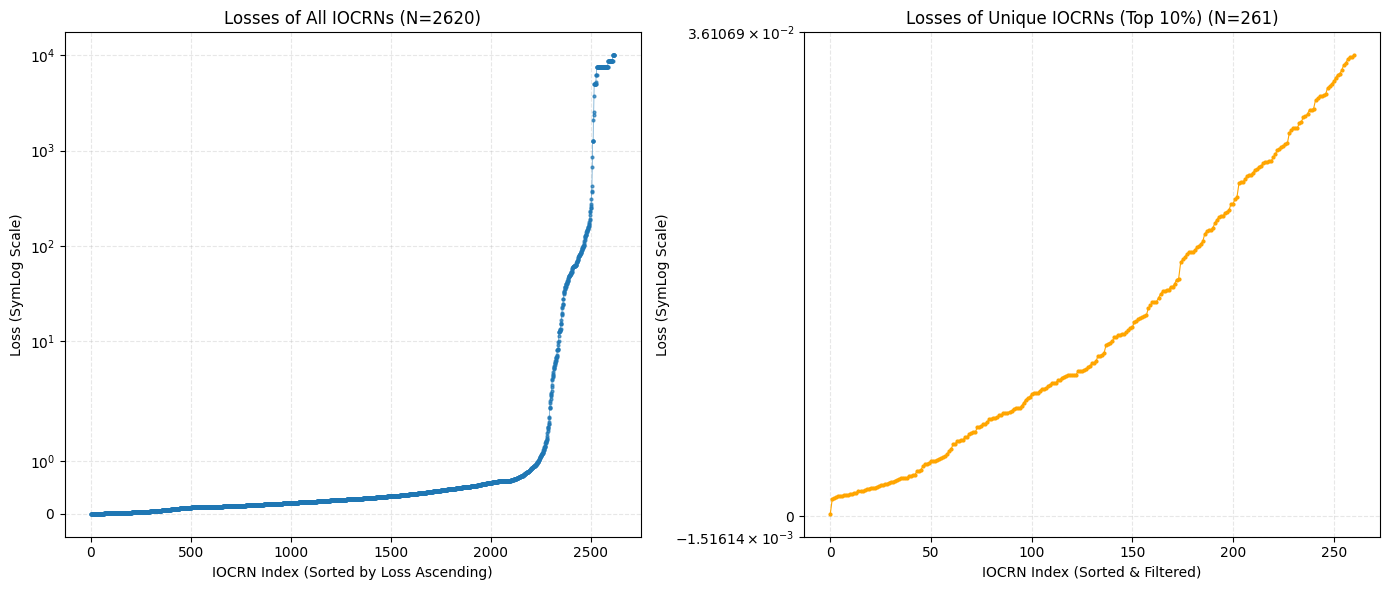

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_unique_rewards(all_iocrns, filter_flag=True, top_percentile=100, figsize=(14, 6)):
    """
    Sorts IOCRNs by reward (loss), optionally filters for topological uniqueness, 
    and plots the reward distribution.

    Args:
        all_iocrns (list): List of IOCRN objects. Each must have .last_task_info['reward'] 
                           and .is_topologically_equal().
        filter_flag (bool): If True, removes topologically duplicate CRNs, keeping the 
                            best-performing version of each topology.
        top_percentile (float): If < 100, restricts the "Unique" plot to the top X% 
                                of topologies. (e.g., 10 = top 10%).
        figsize (tuple): Figure size for the plot.
    """
    
    # 1. Sort all IOCRNs by reward/loss.
    # User Request: "Plotting a loss" -> "Lower values on the left".
    # This implies Ascending Order (Smallest/Best -> Largest/Worst).
    all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)

    # 2. Filter topologically unique IOCRNs
    if filter_flag:
        print("Filtering topologically unique IOCRNs...")
        all_iocrns_sorted_filtered = []
        
        if all_iocrns_sorted:
            # The list is sorted [Best, ..., Worst].
            # To keep the BEST version of each topology, we iterate FORWARD.
            # The first time we see a topology, it is the best one (lowest index in sorted list).
            unique_indices = []
            seen_topologies = []
            
            for i in range(len(all_iocrns_sorted)):
                candidate = all_iocrns_sorted[i]
                is_new = True
                for seen in seen_topologies:
                    if candidate.is_topologically_equal(seen):
                        is_new = False
                        break
                
                if is_new:
                    seen_topologies.append(candidate)
                    unique_indices.append(i)
            
            all_iocrns_sorted_filtered = [all_iocrns_sorted[i] for i in unique_indices]
            
        print(f"Number of topologically unique IOCRNs: {len(all_iocrns_sorted_filtered)} out of {len(all_iocrns_sorted)} total IOCRNs.")

    else:
        all_iocrns_sorted_filtered = all_iocrns_sorted

    # 3. Apply Percentile Cutoff (to the Filtered list)
    if top_percentile < 100:
        n_total = len(all_iocrns_sorted_filtered)
        n_keep = max(1, int(n_total * (top_percentile / 100.0)))
        
        # Keep the FIRST n_keep items (Lowest Loss / Best Performance)
        all_iocrns_sorted_filtered = all_iocrns_sorted_filtered[:n_keep]
        title_suffix = f" (Top {top_percentile}%)"
    else:
        title_suffix = ""

    # 4. Extract Rewards
    rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]
    rewards_sorted_filtered = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted_filtered]

    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Left Plot: All IOCRNs
    ax1.plot(rewards_sorted, marker='o', markersize=2, linestyle='-', linewidth=0.5, alpha=0.7)
    ax1.set_yscale('symlog') # symlog handles negative rewards better than log
    ax1.set_xlabel('IOCRN Index (Sorted by Loss Ascending)')
    ax1.set_ylabel('Loss (SymLog Scale)')
    ax1.set_title(f'Losses of All IOCRNs (N={len(rewards_sorted)})')
    ax1.grid(True, which="both", ls="--", alpha=0.3)

    # Right Plot: Unique / Top Percentile
    ax2.plot(rewards_sorted_filtered, marker='o', color='orange', markersize=2, linestyle='-', linewidth=0.8)
    ax2.set_yscale('symlog') # Kept as symlog
    ax2.set_xlabel('IOCRN Index (Sorted & Filtered)')
    ax2.set_ylabel('Loss (SymLog Scale)')
    ax2.set_title(f'Losses of Unique IOCRNs{title_suffix} (N={len(rewards_sorted_filtered)})')
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    
    # Ensure tick labels are visible on Y axis
    ax2.yaxis.set_minor_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    plt.show()

    return all_iocrns_sorted, all_iocrns_sorted_filtered

# Plot the rewards with filtering and top percentile options
all_iocrns_sorted, all_iocrns_sorted_filtered = plot_unique_rewards(all_iocrns, filter_flag=filter_flag, top_percentile=10, figsize=(14, 6))

In [17]:
# Select the top IOCRNs and top topologically unique IOCRNs to visualize
n_unfiltered = 400
n_filtered = 100

sorting...
done ... 
Unfiltered: IOCRN # 400 has a reward of 0.08032810225370579


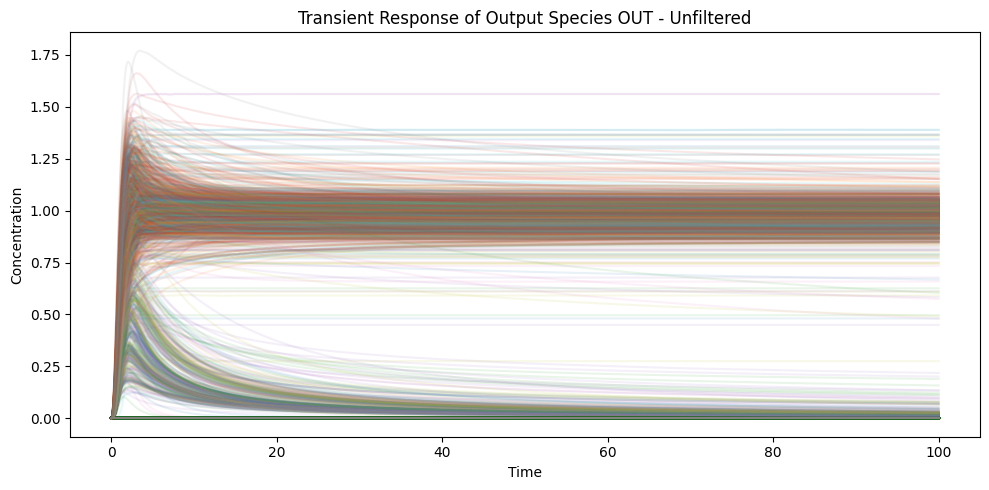

In [18]:
# Plot the responses of the top IOCRNs (topologically not unique)
ax = None
print("sorting...")
all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)
print("done ... ")
for i in range(n_unfiltered):
    x0_list = ic.get_ic(all_iocrns_sorted[i])
    fig, ax = all_iocrns_sorted[i].plot_transient_response(axes=ax, alpha=0.1)
ax[0].set_title(ax[0].get_title() + ' - Unfiltered')
print(f'Unfiltered: IOCRN # {n_unfiltered} has a reward of {all_iocrns_sorted[n_unfiltered-1].last_task_info["reward"]}')

Preparing top 100 trajectories (checking cache first)...
Rendering ensemble...


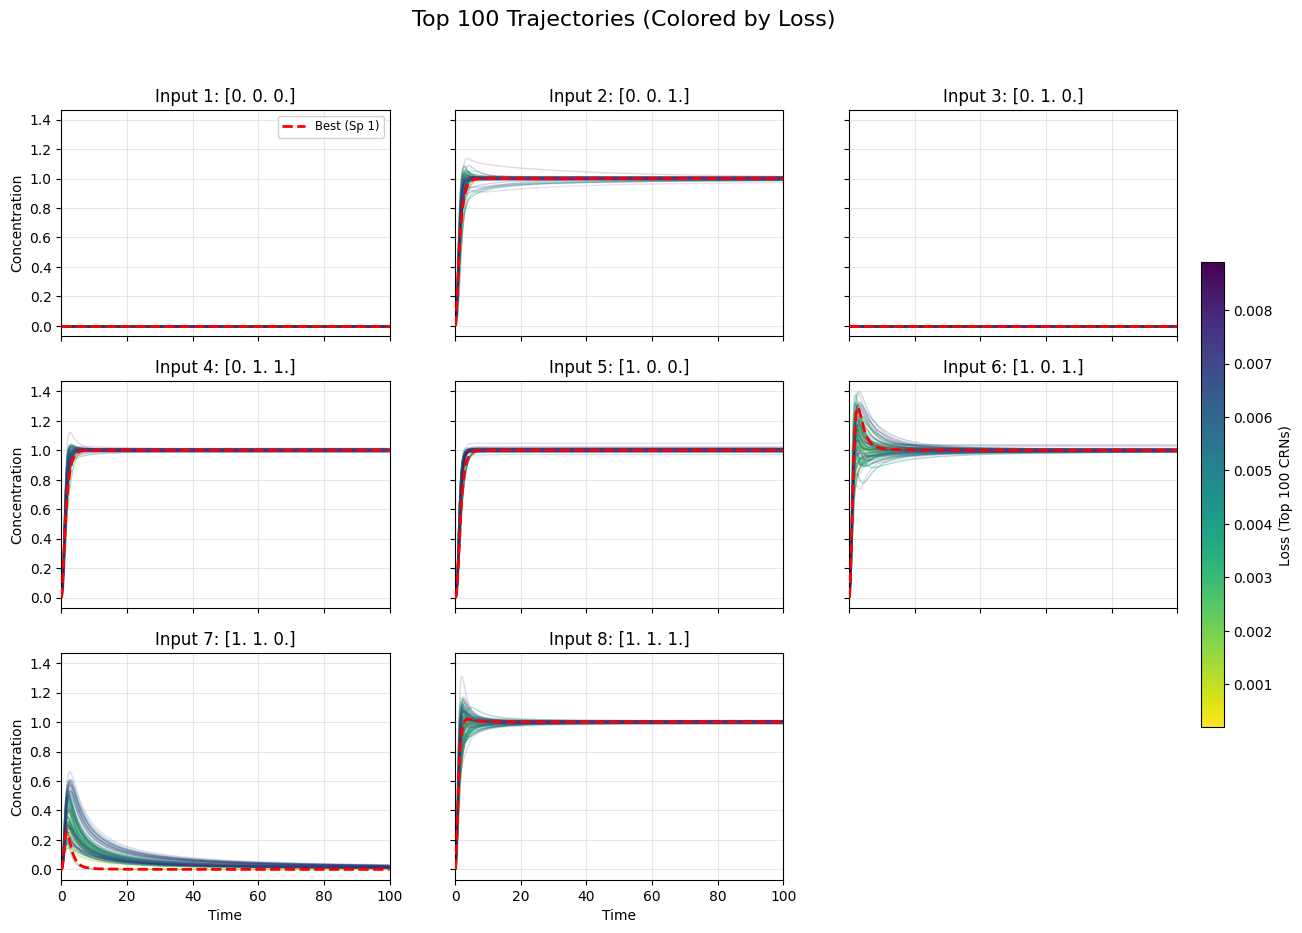

In [19]:


from RL4CRN.utils.visualizations import plot_trajectory_ensemble

# Plot the trajectory ensemble for the top 100 IOCRNs
plot_trajectory_ensemble(
    all_iocrns, 
    ic, 
    u_list, 
    time_horizon, 
    n_top=100,      
    figsize=(15, 10),
    cmap_name="viridis_r", # Reversed: Low Loss (Best) = Yellow/Bright, High Loss = Purple/Dark
    alpha_min=0.1,
    alpha_max=0.6,
    highlight_best=True
)

Filtered: IOCRN # 0 has a reward of 0.00019399918679385427


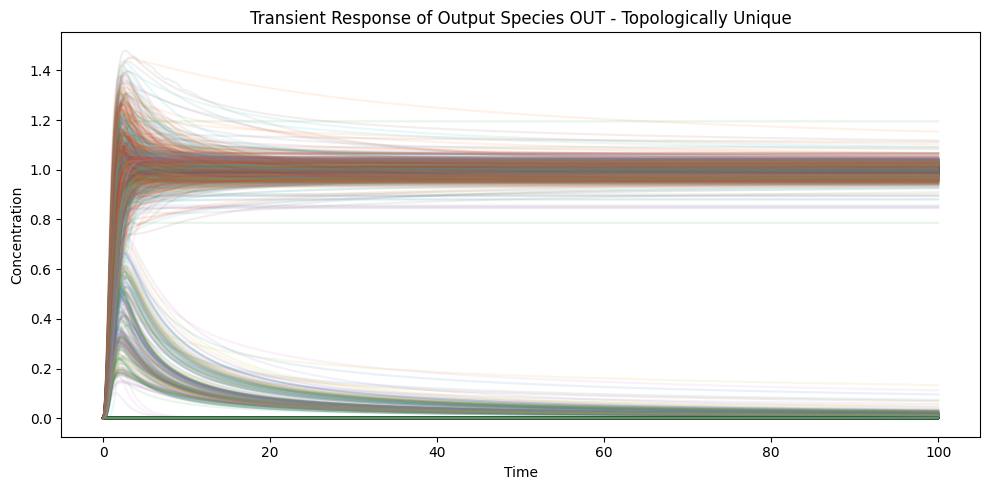

In [20]:
# Plot the responses of the top topologically unique IOCRNs
ax = None
for i in range(len(all_iocrns_sorted_filtered)):
    x0_list = ic.get_ic(all_iocrns_sorted_filtered[i])
    fig, ax = all_iocrns_sorted_filtered[i].plot_transient_response(axes=ax)
ax[0].set_title(ax[0].get_title() + ' - Topologically Unique')
print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')

Preparing top 100 trajectories (checking cache first)...
Rendering ensemble...


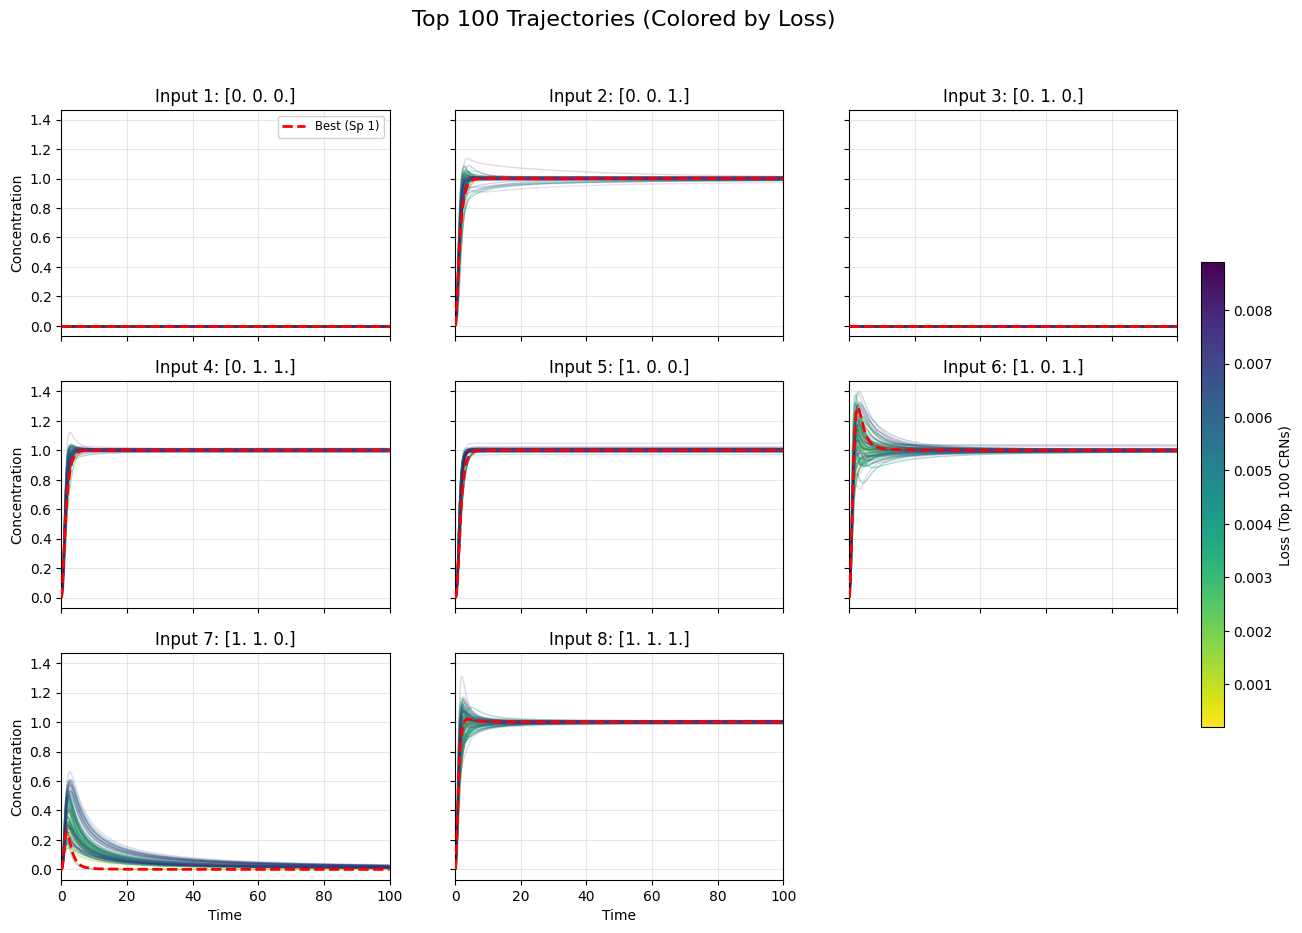

In [21]:
from RL4CRN.utils.visualizations import plot_trajectory_ensemble

# Plot the trajectory ensemble for the top 100 IOCRNs
plot_trajectory_ensemble(
    all_iocrns_sorted_filtered, 
    ic, 
    u_list, 
    time_horizon, 
    n_top=100,      
    figsize=(15, 10),
    cmap_name="viridis_r", # Reversed: Low Loss (Best) = Yellow/Bright, High Loss = Purple/Dark
    alpha_min=0.1,
    alpha_max=0.6,
    highlight_best=True
)

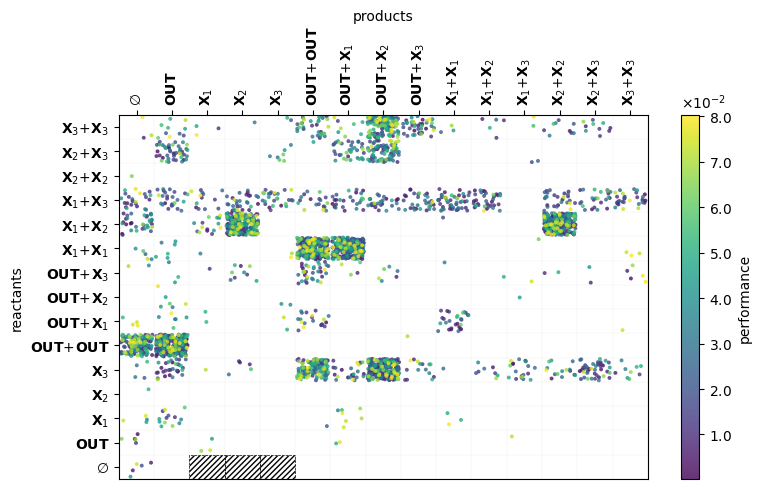

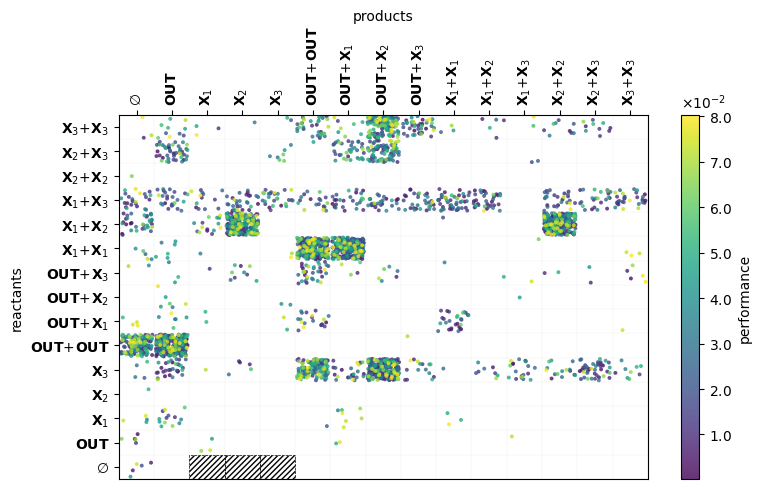

In [22]:
# Plot the reactant-product scatter for the top unfiltered IOCRNs
rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]

# sort species labels to match the number of species in the IOCRNs
species_labels = ['OUT'] + [f'X_{i+1}' for i in range(n_inputs)]
num_reactions_template = 3

plot_reactant_product_scatter(
    all_iocrns_sorted[0:n_unfiltered],
    perf=rewards_sorted[0:n_unfiltered],
    species_labels=species_labels,
    max_order=2,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="viridis",
    max_ticks=40,
    figsize=(8, 5),
    jitter_scale=0.45,
    use_plotly=False  # <--- ENABLE INTERACTIVE PLOTTING WITH PLOTLY
)

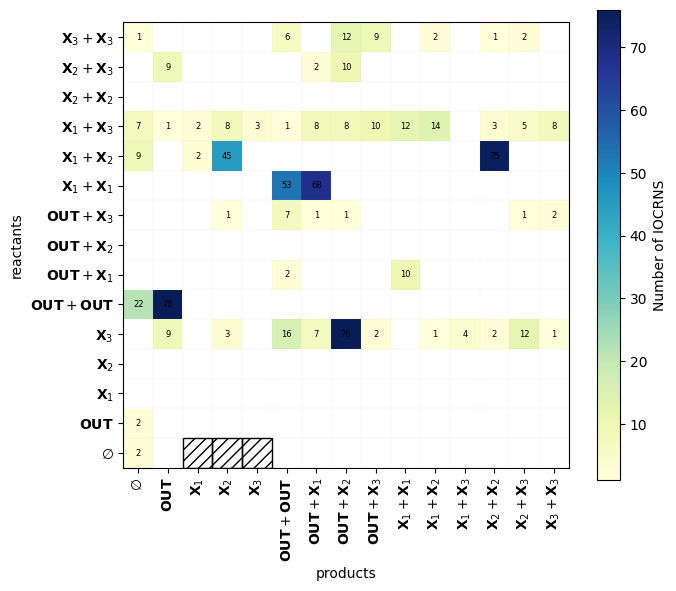

In [28]:
# Plot the reactant-product heatmap for the top filtered IOCRNs (topologically unique)
plot_reactant_product_heatmap(
    all_iocrns_sorted_filtered[0:n_filtered],
    species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="YlGnBu",
    max_ticks=20,
    figsize=(7, 6),
)

Applied reward weighting (alpha=10.0). Edges stretched by fitness gaps.
Computing layout (mds)...
Dual Coloring: Face=Loss (Greyscale), Edge=Cluster (Rainbow) with Black Separator


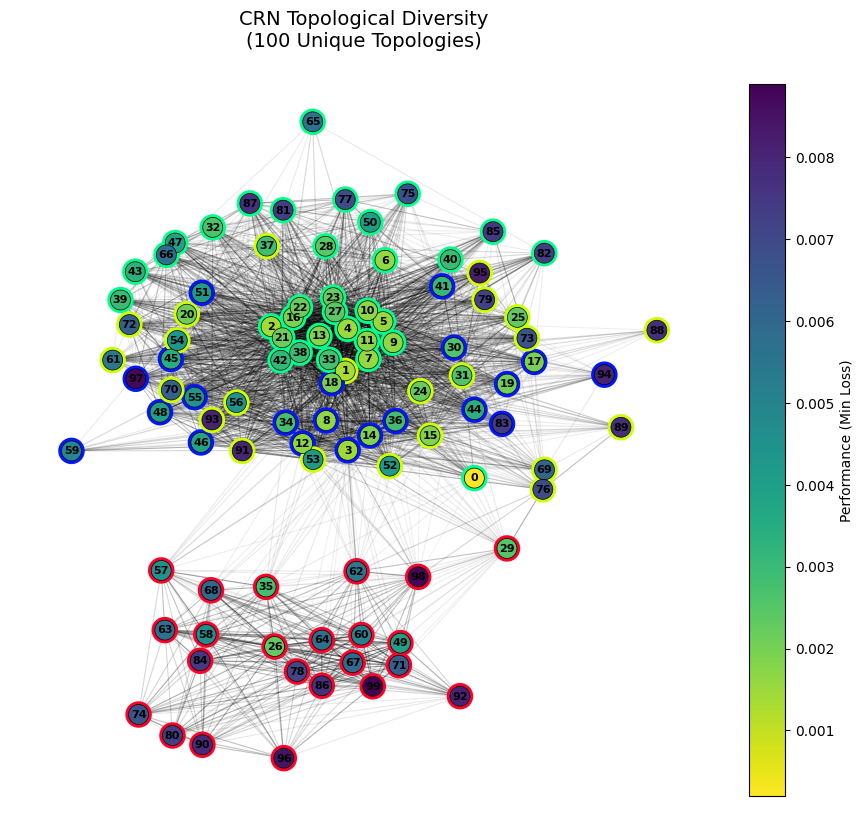

In [29]:
from RL4CRN.utils.visualizations import visualize_crn_diversity
rewards_sorted_filtered = [iocrn.last_task_info.get('reward') for iocrn in all_iocrns_sorted_filtered]
# use unique filtered iocrns

visualize_crn_diversity(
    all_iocrns_sorted_filtered[:n_filtered], 
    perf=rewards_sorted_filtered[:n_filtered], 
    k=None, 
    t=6, 
    layout_method="mds", 
    label_percentile=50, 
    alpha=10.0, 
    unique=True)

In [25]:
print(all_iocrns_sorted_filtered[5])


Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_3 ----> X_1 + X_3;  [MAK(1.0347325801849365)]
X_3 ----> OUT + X_2;  [MAK(0.8573146462440491)]
X_1 + X_1 ----> OUT + X_1;  [MAK(0.9929586052894592)]
X_1 + X_2 ----> X_2 + X_2;  [MAK(1.0065466165542603)]
OUT + OUT ----> OUT;  [MAK(0.9999305605888367)]


In [26]:
print(all_iocrns_sorted_filtered[0])


Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_3 ----> OUT;  [MAK(0.9882016181945801)]
X_3 ----> OUT + X_2;  [MAK(0.9121172428131104)]
OUT ----> ∅;  [MAK(1.0003230571746826)]
X_1 + X_1 ----> OUT + OUT;  [MAK(0.8015768527984619)]
X_1 + X_2 ----> X_2 + X_2;  [MAK(0.9940165281295776)]


In [27]:
print(all_iocrns_sorted_filtered[25])

Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_3 ----> OUT + X_1;  [MAK(0.9352574944496155)]
X_3 ----> OUT + X_2;  [MAK(1.1221626996994019)]
X_1 + X_1 ----> OUT + X_1;  [MAK(1.0233643054962158)]
X_1 + X_2 ----> X_2;  [MAK(0.9362868666648865)]
X_1 + X_2 ----> X_2 + X_2;  [MAK(0.9875854849815369)]
X_3 + X_3 ----> OUT + X_3;  [MAK(0.9886197447776794)]
OUT + X_3 ----> X_3 + X_3;  [MAK(0.8808124661445618)]
OUT + OUT ----> OUT;  [MAK(1.0031182765960693)]


Filtered: IOCRN # 0 has a reward of 0.00019399918679385427
Filtered: IOCRN # 99 has a reward of 0.008896601043042168


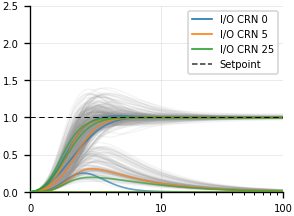

In [35]:
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
save_figures_flag = True

iocrn_indices_to_highlight = [0, 5, 25]  # Indices of IOCRNs to highlight in the plot
# Transient dynamics plot
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

fig, ax = plt.subplots(figsize=(2.5, 1.85), constrained_layout=True) 

# --------- Plot all traces in light gray (topologically unique) ----------
alpha_bg = 0.1     # transparency for background traces
lw_bg = 0.8         # line width for background traces
time_shift = 1      # shift time to avoid log(0)

for i in range(n_filtered):
    info = all_iocrns_sorted_filtered[i].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]

    for j in range(len(outs)):
        ax.plot(t, outs[j][0, :],
                color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)

print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')
print(f'Filtered: IOCRN # {n_filtered-1} has a reward of {all_iocrns_sorted_filtered[n_filtered-1].last_task_info["reward"]}')

# --------- Highlight the selected IOCRNs ----------
lw_hi = 1

for i in range(len(iocrn_indices_to_highlight)):
    info = all_iocrns_sorted_filtered[iocrn_indices_to_highlight[i]].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]

    color = f"C{i}"  # Matplotlib standard cycle
    label = f"I/O CRN {i+1}"

    for j in range(len(outs)):
        ax.plot(
            t, outs[j][0, :],
            alpha=u_list[j][1] / 1.5,          # keep your per-trace alpha
            color=color, linewidth=lw_hi,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )

# --------- Axes cosmetics ----------
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --------- Scales/limits (set before setpoint lines so we know xmin/xmax) ----------
ax.set_xscale("log")
ax.set_ylim(0, 2.5)
ax.set_xlim(time_shift, t_f + time_shift)

# 1) dashed setpoint lines from u_list[*][1]
xmin, xmax = ax.get_xlim()
for j in range(len(u_list)):
    sp = u_list[j][1]  # "entry one" (index 1)
    ax.hlines(
        y=sp, xmin=xmin, xmax=xmax,
        colors="k",
        linewidth=0.3,
        linestyle=(0, (10, 8)),  # (dash_length, gap_length) -> larger gap
        zorder=3
    )

# 2) Legend for colored lines should not have alpha:
#    use proxy artists with alpha=1 so legend is fully opaque.
color_handles = [Line2D([0], [0], color=f"C{i}", lw=lw_hi, alpha=1.0) for i in range(len(iocrn_indices_to_highlight))]
color_labels  = [f"I/O CRN {i}" for i in iocrn_indices_to_highlight]

# Dashed Line for Setpoint
setpoint_handle = Line2D([0], [0], color="0.2", lw=0.9, ls="--")
handles = color_handles + [setpoint_handle]
labels  = color_labels + ["Setpoint"]

ax.set_xticks(np.array([0, 10, 100]) + time_shift)
ax.set_xticklabels(ax.get_xticks() - time_shift, rotation=0)

ax.legend(handles=handles, labels=labels, frameon=True, loc="upper right", handlelength=2)
plt.show()

if save_figures_flag is True:
    fig.savefig(os.path.join(target_directory, 'plots', "Logic_4pecies_5rxns_transient_dynamics.pdf"))

In [51]:
all_iocrns_sorted_filtered[25].last_task_info['outputs'][0][0][-1]

np.float64(0.0)

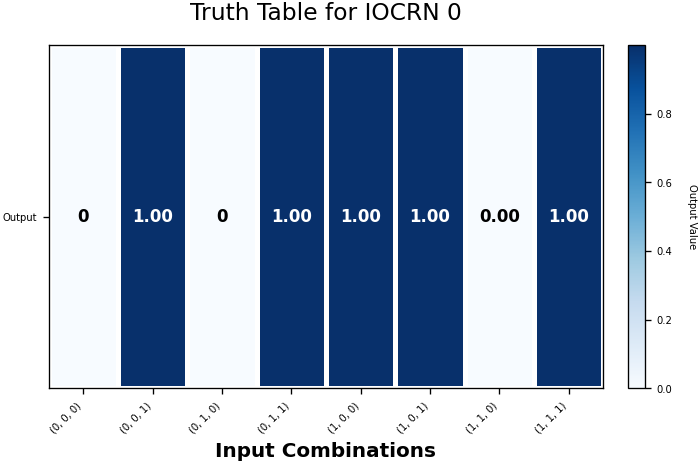

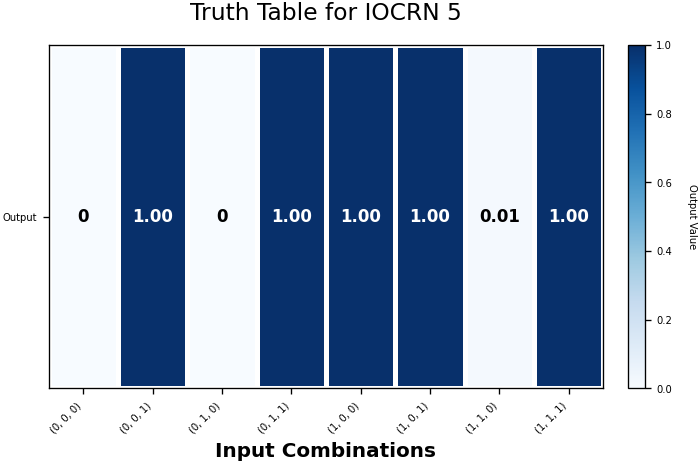

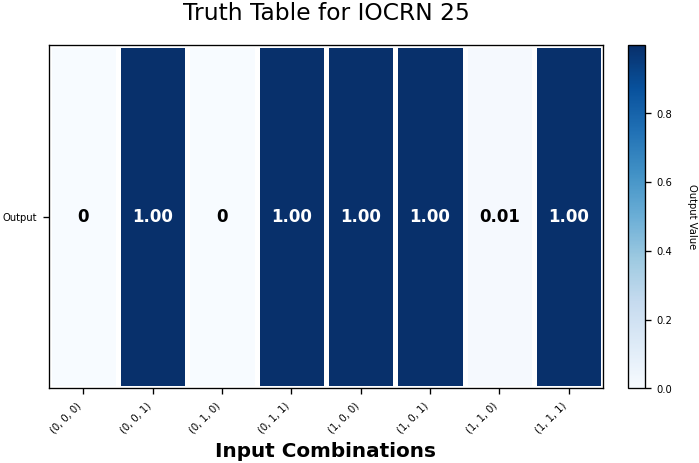

In [55]:
def get_outputs(iocrn):
    return [o[0][-1] for o in iocrn.last_task_info['outputs']]


for i in [0, 5, 25]:
    plot_truth_table(
        u_list,
        get_outputs(all_iocrns_sorted_filtered[i]),
        title=f"Truth Table for IOCRN {i}"
    )

pass